# 04 Bivariate EDA

This notebook examines relationships between variables in the Q1 2025 Yellow Taxi analytical dataset. The focus is business intelligence: demand timing, geographic concentration, revenue patterns, payment behavior, and operating efficiency.

No preprocessing, feature engineering, predictive modeling, or machine learning is performed here.

## TOR Focus

Section 6.2 requires bivariate EDA covering hour of day versus trip volume, geography versus revenue or trip count, payment type versus tip or total amount, distance versus total amount, and weekday versus demand. Section 5.2 expects executive-ready charts, KPIs, major insights, business implications, and concise caveats.

In [1]:
from pathlib import Path
import os
import tempfile

MPLCONFIG_DIR = Path(tempfile.gettempdir()) / "data_vis_project_matplotlib"
MPLCONFIG_DIR.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

import numpy as np
import pandas as pd
import matplotlib

if "get_ipython" not in globals():
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "bold",
})

PRIMARY = "#1f77b4"
SECONDARY = "#4c78a8"
ACCENT = "#f58518"
GREEN = "#54a24b"
RED = "#e45756"
NEUTRAL = "#6b7280"

## Load Analytical Dataset and Review Features

Only columns needed for bivariate operational EDA are loaded. The reporting window is restricted to Q1 2025 to avoid letting a small number of date anomalies distort time-based charts.

In [2]:
PROJECT_ROOT = Path.cwd()
ANALYTICAL_PATH = PROJECT_ROOT / "Data" / "processed" / "analytical" / "analytical.parquet"

if not ANALYTICAL_PATH.exists():
    raise FileNotFoundError(f"Analytical dataset not found: {ANALYTICAL_PATH}")

BIVARIATE_COLUMNS = [
    "pickup_date", "pickup_hour", "pickup_day", "is_weekend",
    "pickup_borough", "dropoff_borough", "pickup_zone", "dropoff_zone",
    "payment_type", "trip_distance", "trip_duration_min", "avg_speed_mph",
    "fare_amount", "total_amount", "tip_percent",
]

eda = pd.read_parquet(ANALYTICAL_PATH, columns=BIVARIATE_COLUMNS)
eda["pickup_date"] = pd.to_datetime(eda["pickup_date"], errors="coerce")

q1_mask = eda["pickup_date"].between(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-03-31"))
analysis = eda.loc[q1_mask].copy()
out_of_period_rows = int((~q1_mask).sum())

print(f"Loaded: {ANALYTICAL_PATH}")
print(f"Rows loaded: {len(eda):,}")
print(f"Rows used for Q1 bivariate EDA: {len(analysis):,}")
print(f"Rows outside Q1 2025 excluded from bivariate charts: {out_of_period_rows:,}")
analysis.head()

Loaded: c:\Users\abd\Desktop\Data-Vis-Project\Data\processed\analytical\analytical.parquet
Rows loaded: 11,198,026
Rows used for Q1 bivariate EDA: 11,198,001
Rows outside Q1 2025 excluded from bivariate charts: 25


,pickup_date,pickup_hour,pickup_day,is_weekend,pickup_borough,dropoff_borough,pickup_zone,dropoff_zone,payment_type,trip_distance,trip_duration_min,avg_speed_mph,fare_amount,total_amount,tip_percent
0,2025-01-01,0,Wednesday,False,Manhattan,Manhattan,Sutton Place/Turtle Bay North,Upper East Side South,1,1.60,8.35,11.50,10.00,18.00,30.00
1,2025-01-01,0,Wednesday,False,Manhattan,Manhattan,Upper East Side North,Upper East Side South,1,0.50,2.55,11.76,5.10,12.12,39.61
2,2025-01-01,0,Wednesday,False,Manhattan,Manhattan,Lenox Hill West,Lenox Hill West,1,0.60,1.95,18.46,5.10,12.10,39.22
3,2025-01-01,0,Wednesday,False,Manhattan,Manhattan,Washington Heights South,Washington Heights South,2,0.52,5.57,5.60,7.20,9.70,0.00
4,2025-01-01,0,Wednesday,False,Manhattan,Manhattan,Washington Heights South,Hamilton Heights,2,0.66,3.53,11.21,5.80,8.30,0.00


In [3]:
feature_review = pd.DataFrame({
    "column": analysis.columns,
    "dtype": [str(dtype) for dtype in analysis.dtypes],
    "missing_rows": [int(analysis[column].isna().sum()) for column in analysis.columns],
    "missing_pct": [analysis[column].isna().mean() * 100 for column in analysis.columns],
})
feature_review

,column,dtype,missing_rows,missing_pct
0,pickup_date,datetime64[ns],0,0.00
1,pickup_hour,Int64,0,0.00
2,pickup_day,object,0,0.00
3,is_weekend,boolean,0,0.00
4,pickup_borough,object,0,0.00
5,dropoff_borough,object,0,0.00
6,pickup_zone,object,0,0.00
7,dropoff_zone,object,0,0.00
8,payment_type,int64,0,0.00
9,trip_distance,float64,0,0.00


**Most useful bivariate variables for operational analysis:** pickup hour, pickup day, weekend flag, pickup/dropoff borough, pickup/dropoff zone, payment type, trip distance, trip duration, average speed, fare amount, total amount, and tip percent.

**Data caveat:** Recorded revenue charts use `total_amount` as provided in the analytical layer. Average and scatterplot views use positive, percentile-bounded values so extreme records do not hide the normal operating pattern.

## Helper Functions

These helpers keep formatting consistent and avoid repeated plotting code. Large scatterplots use sampling for performance and readability.

In [4]:
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
PAYMENT_LABELS = {
    0: "0 - Flex/missing",
    1: "1 - Credit card",
    2: "2 - Cash",
    3: "3 - No charge",
    4: "4 - Dispute",
    5: "5 - Unknown",
    6: "6 - Voided",
}

analysis["payment_label"] = analysis["payment_type"].map(PAYMENT_LABELS).fillna("Other")
analysis["day_type"] = np.where(analysis["is_weekend"].fillna(False), "Weekend", "Weekday")

# Percentile-bounded view for average metrics and scatterplots.
distance_p99 = analysis["trip_distance"].quantile(0.99)
duration_p99 = analysis["trip_duration_min"].quantile(0.99)
total_p99 = analysis["total_amount"].quantile(0.99)
fare_p99 = analysis["fare_amount"].quantile(0.99)

common_metric = analysis[
    analysis["trip_distance"].gt(0)
    & analysis["trip_distance"].le(distance_p99)
    & analysis["trip_duration_min"].gt(0)
    & analysis["trip_duration_min"].le(duration_p99)
    & analysis["total_amount"].gt(0)
    & analysis["total_amount"].le(total_p99)
    & analysis["fare_amount"].gt(0)
    & analysis["fare_amount"].le(fare_p99)
].copy()

print(f"Rows in percentile-bounded metric view: {len(common_metric):,}")
print(f"Distance p99: {distance_p99:,.2f} miles | Duration p99: {duration_p99:,.2f} minutes | Total amount p99: ${total_p99:,.2f}")

Rows in percentile-bounded metric view: 10,122,550
Distance p99: 19.34 miles | Duration p99: 61.52 minutes | Total amount p99: $102.11


In [5]:
def money_millions(values):
    return values / 1_000_000


def plot_bar(series, title, xlabel, ylabel, color=PRIMARY, rotation=30, value_labels=False, money_axis=False):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    y = money_millions(series.values) if money_axis else series.values
    sns.barplot(x=series.index.astype(str), y=y, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    if value_labels:
        labels = [f"${v:,.1f}M" if money_axis else f"{v:,.0f}" for v in y]
        for container in ax.containers:
            ax.bar_label(container, labels=labels, fontsize=9, padding=3)
    plt.tight_layout()
    plt.show()


def plot_grouped_bar(df, x, y, hue, title, xlabel, ylabel, palette=None, rotation=0):
    fig, ax = plt.subplots(figsize=(12, 5.8))
    sns.barplot(data=df, x=x, y=y, hue=hue, palette=palette, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_line(df, x, y, title, xlabel, ylabel, hue=None):
    fig, ax = plt.subplots(figsize=(12, 5.8))
    sns.lineplot(data=df, x=x, y=y, hue=hue, marker="o", linewidth=2.2, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if hue:
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def sample_for_scatter(df, n=120_000, random_state=42):
    if len(df) <= n:
        return df
    return df.sample(n=n, random_state=random_state)

# 1. Hour of Day vs Trip Volume

This view identifies when demand is concentrated during the operating day.

In [6]:
hourly = analysis.groupby("pickup_hour").size().rename("trip_count").sort_index()
hourly_day_type = analysis.groupby(["pickup_hour", "day_type"]).size().reset_index(name="trip_count")

hourly_summary = pd.DataFrame({
    "metric": ["peak_hour", "peak_hour_trips", "lowest_hour", "lowest_hour_trips"],
    "value": [hourly.idxmax(), hourly.max(), hourly.idxmin(), hourly.min()],
})
hourly_summary

,metric,value
0,peak_hour,18
1,peak_hour_trips,843230
2,lowest_hour,4
3,lowest_hour_trips,76265


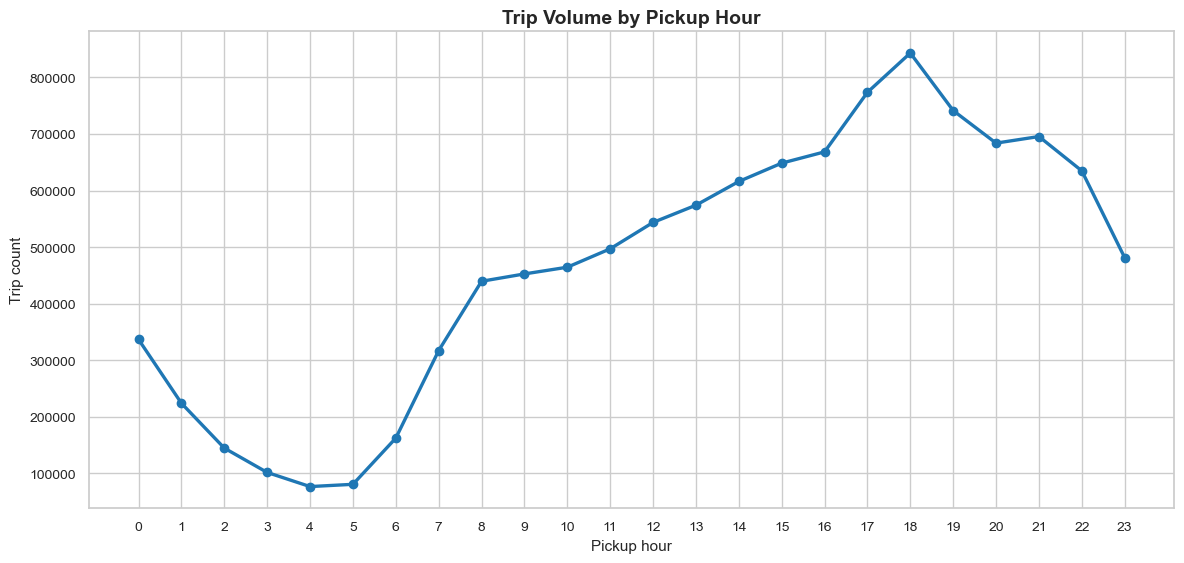

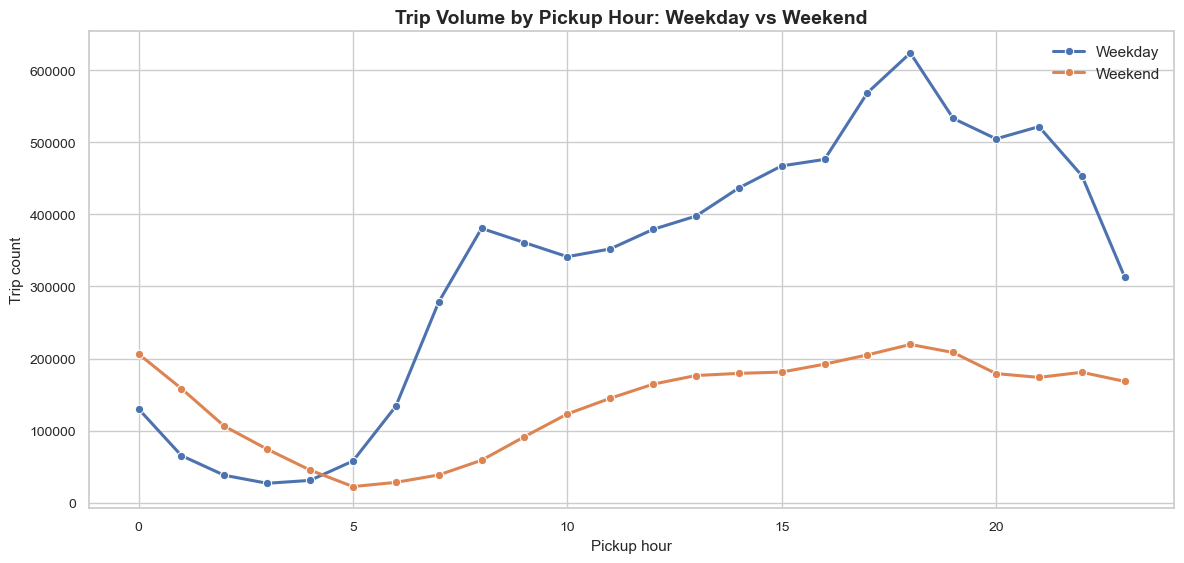

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(hourly.index, hourly.values, marker="o", linewidth=2.4, color=PRIMARY)
ax.set_title("Trip Volume by Pickup Hour")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Trip count")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

plot_line(
    hourly_day_type,
    x="pickup_hour",
    y="trip_count",
    hue="day_type",
    title="Trip Volume by Pickup Hour: Weekday vs Weekend",
    xlabel="Pickup hour",
    ylabel="Trip count",
)

**Observation:** Trip volume peaks in the early evening, especially around 18:00, while overnight hours show the lowest demand.

**Interpretation:** Demand is strongest after the traditional workday and remains active through the evening, while late-night and early-morning periods are materially lighter.

**Business implication:** Driver availability and dispatch coverage should be strongest from late afternoon through evening, with leaner staffing during the overnight trough.

# 2. Weekday vs Demand

Weekday demand shows how passenger behavior changes across the week and whether weekends require different operating assumptions.

In [8]:
weekday_counts = analysis.groupby("pickup_day").size().reindex(WEEKDAY_ORDER)
day_type_counts = analysis.groupby("day_type").size().reindex(["Weekday", "Weekend"])
weekday_table = pd.DataFrame({
    "trip_count": weekday_counts,
    "share_pct": weekday_counts / len(analysis) * 100,
})
weekday_table

,trip_count,share_pct
pickup_day,,
Monday,1317997,11.77
Tuesday,1429380,12.76
Wednesday,1634116,14.59
Thursday,1768736,15.80
Friday,1720914,15.37
Saturday,1831466,16.36
Sunday,1495392,13.35


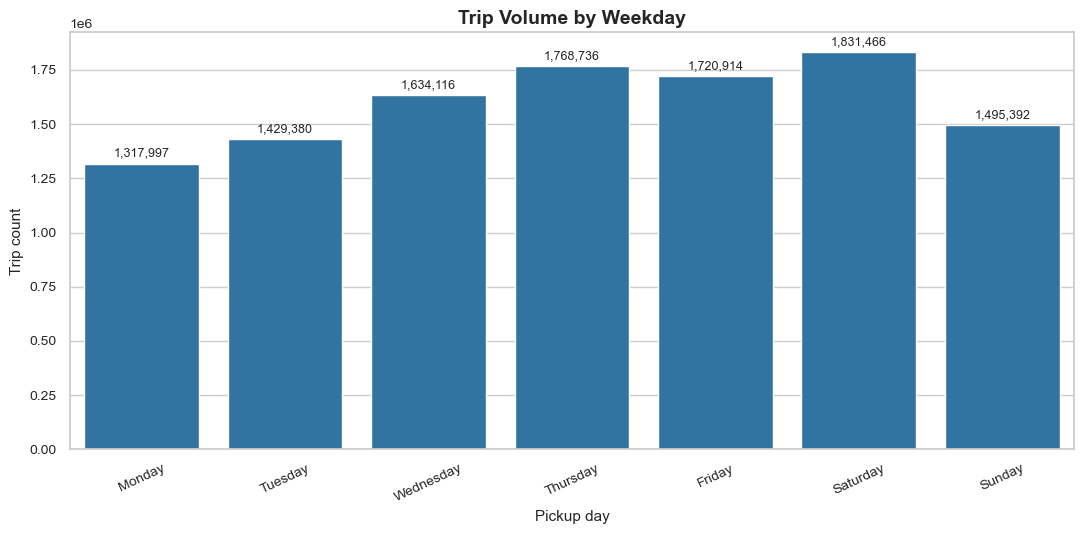

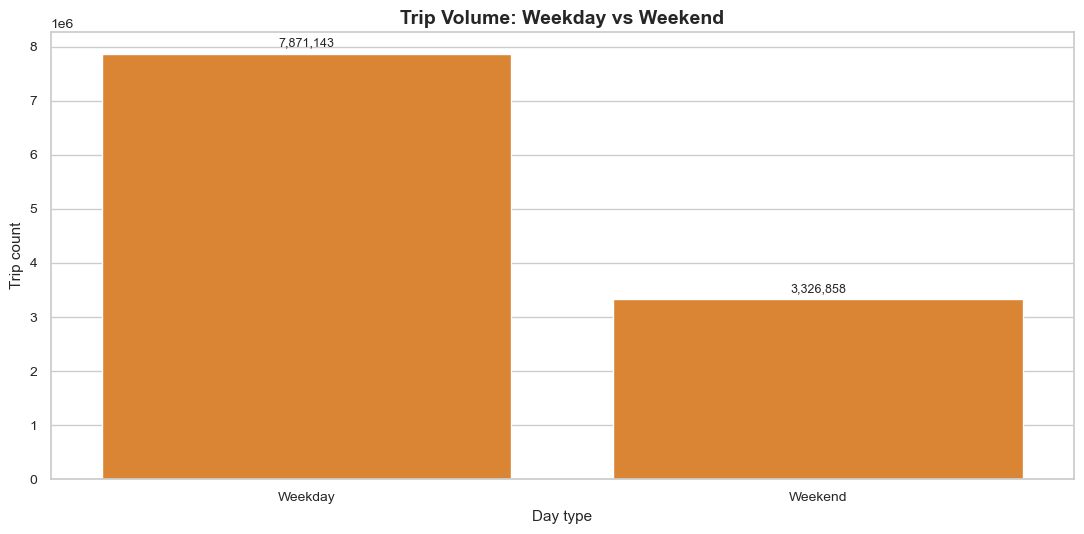

In [9]:
plot_bar(weekday_counts, "Trip Volume by Weekday", "Pickup day", "Trip count", color=PRIMARY, rotation=25, value_labels=True)
plot_bar(day_type_counts, "Trip Volume: Weekday vs Weekend", "Day type", "Trip count", color=ACCENT, rotation=0, value_labels=True)

**Observation:** Saturday records the highest single-day-of-week volume, with Thursday and Friday also strong. Weekdays carry most total trips because there are five weekdays each week.

**Interpretation:** Demand is not purely commuter-driven; weekend and late-week activity are important parts of the operating pattern.

**Business implication:** Planning should not reduce weekend coverage too aggressively. Saturday service levels deserve specific attention in staffing and fleet deployment.

# 3. Geography vs Trip Count

Geography identifies where demand originates and where trips end. This section uses borough and zone metadata attached in the analytical layer.

In [10]:
pickup_borough_counts = analysis.groupby("pickup_borough").size().sort_values(ascending=False)
dropoff_borough_counts = analysis.groupby("dropoff_borough").size().sort_values(ascending=False)
top_pickup_zones = analysis.groupby("pickup_zone").size().sort_values(ascending=False).head(15)
top_dropoff_zones = analysis.groupby("dropoff_zone").size().sort_values(ascending=False).head(15)

geo_count_table = pd.DataFrame({
    "pickup_trips": pickup_borough_counts,
    "dropoff_trips": dropoff_borough_counts,
}).fillna(0).astype(int)
geo_count_table

,pickup_trips,dropoff_trips
Manhattan,9827095,9927892
Queens,965052,565417
Brooklyn,306011,522571
Bronx,70406,89034
Unknown,27391,69537
EWR,1056,21181
Staten Island,990,2369


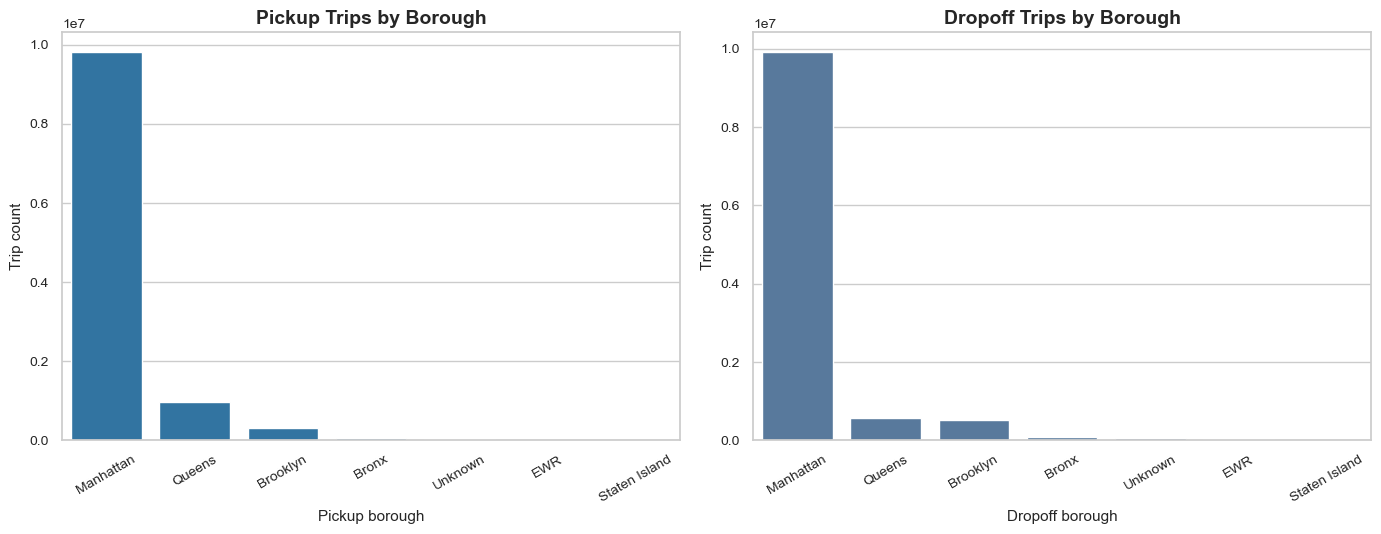

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(x=pickup_borough_counts.index, y=pickup_borough_counts.values, color=PRIMARY, ax=axes[0])
axes[0].set_title("Pickup Trips by Borough")
axes[0].set_xlabel("Pickup borough")
axes[0].set_ylabel("Trip count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=dropoff_borough_counts.index, y=dropoff_borough_counts.values, color=SECONDARY, ax=axes[1])
axes[1].set_title("Dropoff Trips by Borough")
axes[1].set_xlabel("Dropoff borough")
axes[1].set_ylabel("Trip count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

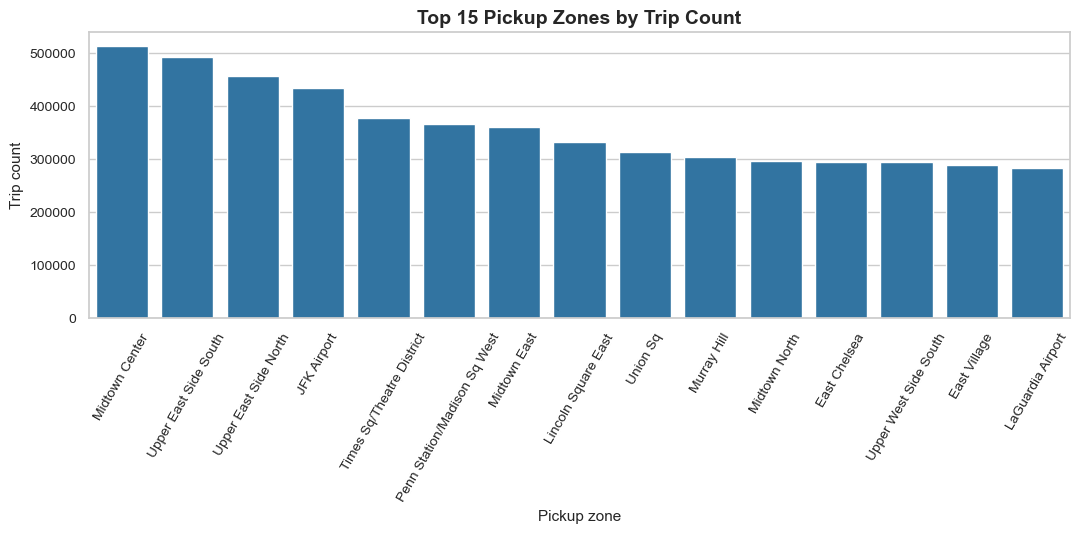

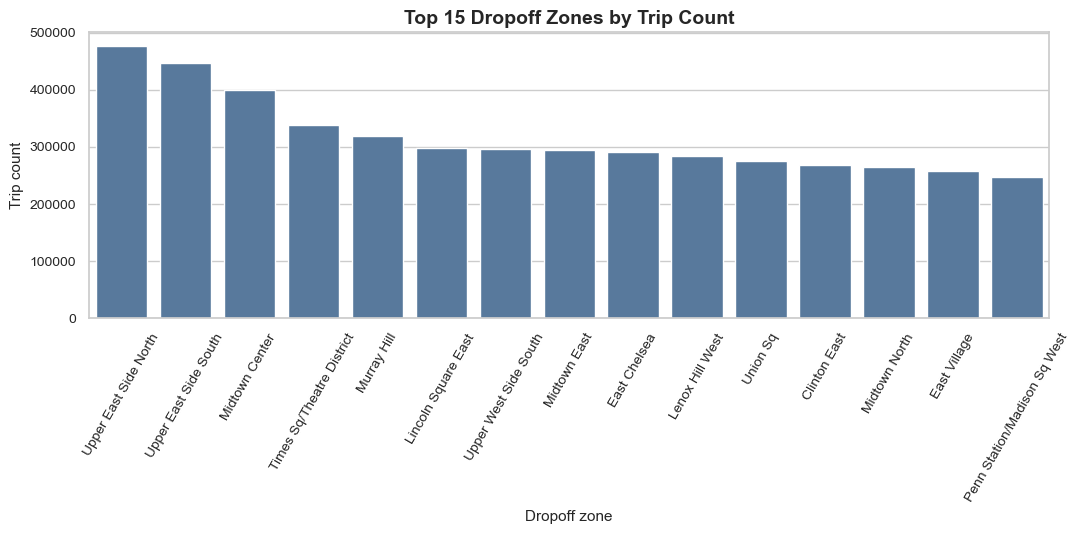

In [12]:
plot_bar(top_pickup_zones, "Top 15 Pickup Zones by Trip Count", "Pickup zone", "Trip count", color=PRIMARY, rotation=60)
plot_bar(top_dropoff_zones, "Top 15 Dropoff Zones by Trip Count", "Dropoff zone", "Trip count", color=SECONDARY, rotation=60)

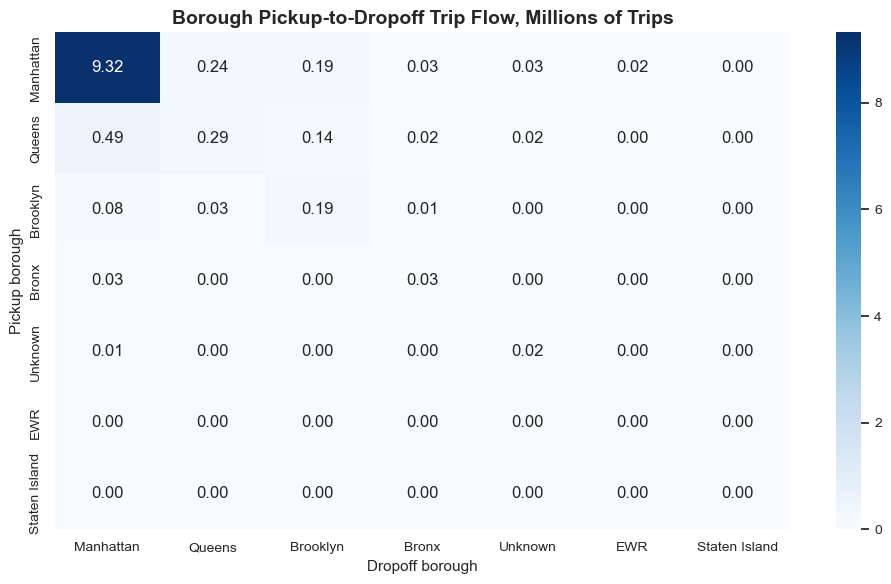

In [13]:
borough_flow = analysis.pivot_table(
    index="pickup_borough",
    columns="dropoff_borough",
    values="total_amount",
    aggfunc="size",
    fill_value=0,
)
borough_flow = borough_flow.loc[pickup_borough_counts.index, dropoff_borough_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(borough_flow / 1_000_000, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Borough Pickup-to-Dropoff Trip Flow, Millions of Trips")
ax.set_xlabel("Dropoff borough")
ax.set_ylabel("Pickup borough")
plt.tight_layout()
plt.show()

**Observation:** Manhattan dominates both pickup and dropoff volume. Midtown, Upper East Side, JFK Airport, Times Square, and Penn Station-area zones are among the strongest demand generators.

**Interpretation:** Yellow taxi demand is highly concentrated in central Manhattan and major transportation nodes.

**Business implication:** High-frequency coverage should prioritize Manhattan core zones and airport corridors, while borough flow patterns can guide repositioning decisions.

# 4. Geography vs Revenue

This section compares where revenue is generated and which zones produce high-value trips.

In [14]:
borough_revenue = analysis.groupby("pickup_borough")["total_amount"].sum().sort_values(ascending=False)
zone_revenue = analysis.groupby("pickup_zone").agg(
    trips=("total_amount", "size"),
    total_revenue=("total_amount", "sum"),
).sort_values("total_revenue", ascending=False).head(15)

zone_avg_fare = common_metric.groupby("pickup_zone").agg(
    trips=("fare_amount", "size"),
    avg_fare=("fare_amount", "mean"),
    avg_total=("total_amount", "mean"),
).query("trips >= 5000").sort_values("avg_fare", ascending=False).head(15)

borough_revenue_table = pd.DataFrame({"recorded_revenue": borough_revenue})
borough_revenue_table

,recorded_revenue
pickup_borough,
Manhattan,"217,014,509.40"
Queens,"58,892,498.33"
Brooklyn,"8,246,293.37"
Bronx,"2,114,423.34"
Unknown,"1,023,748.78"
EWR,"101,067.30"
Staten Island,"38,497.45"


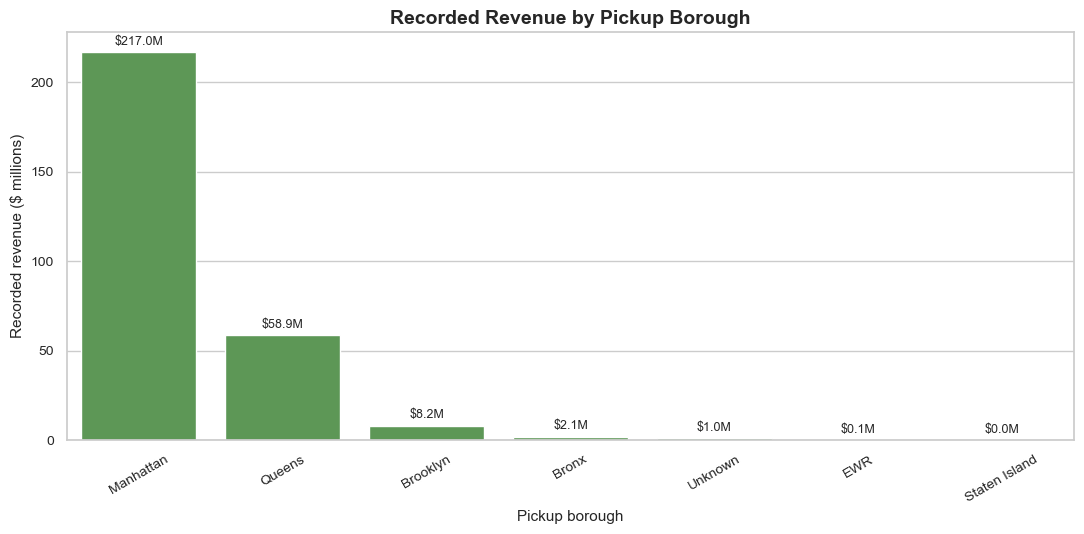

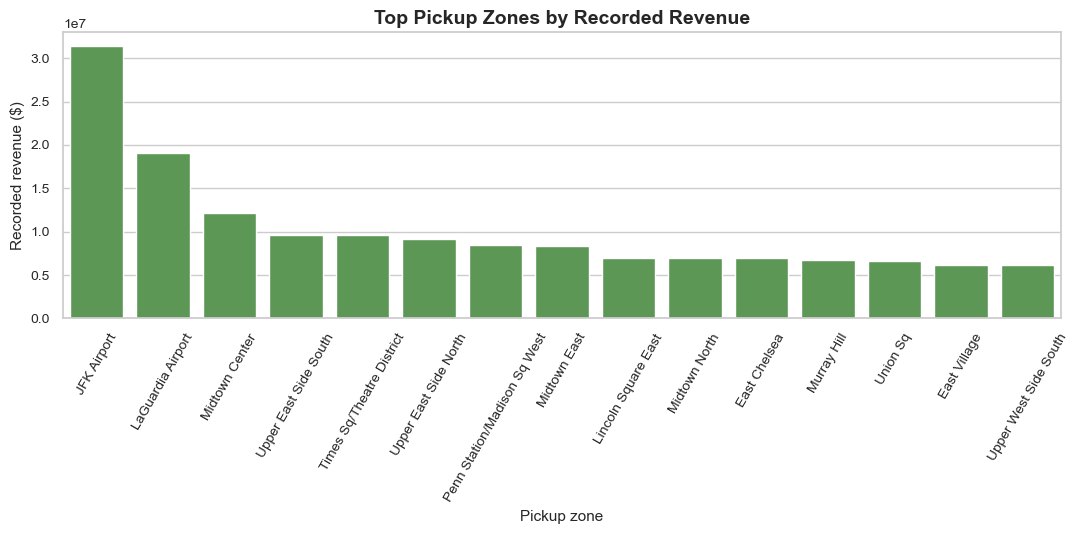

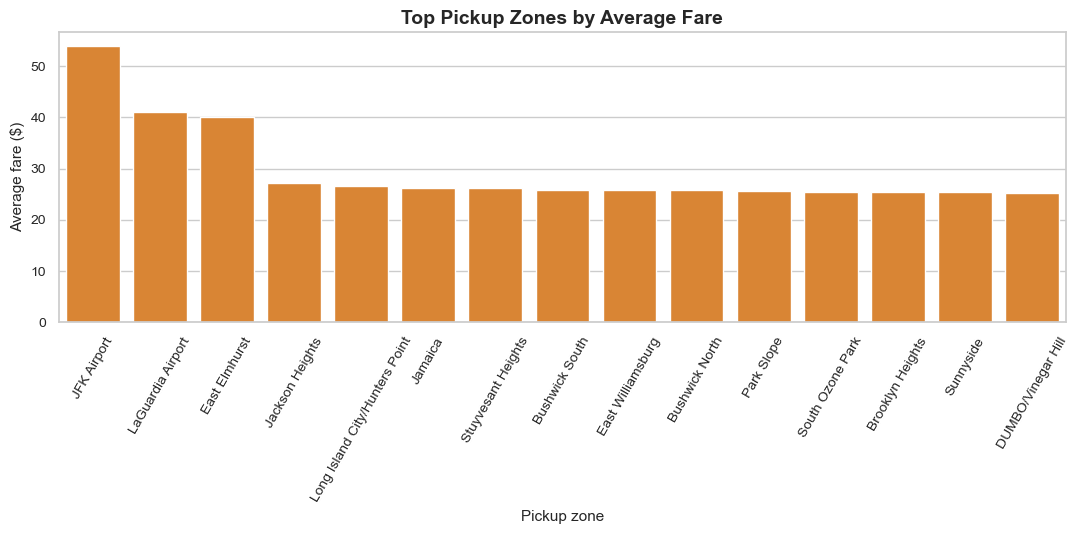

In [15]:
plot_bar(borough_revenue, "Recorded Revenue by Pickup Borough", "Pickup borough", "Recorded revenue ($ millions)", color=GREEN, rotation=30, value_labels=True, money_axis=True)
plot_bar(zone_revenue["total_revenue"], "Top Pickup Zones by Recorded Revenue", "Pickup zone", "Recorded revenue ($)", color=GREEN, rotation=60)
plot_bar(zone_avg_fare["avg_fare"], "Top Pickup Zones by Average Fare", "Pickup zone", "Average fare ($)", color=ACCENT, rotation=60)

**Observation:** Manhattan generates the largest total recorded revenue because of its overwhelming volume. Airports, especially JFK and LaGuardia, stand out as high-revenue and high-average-fare zones.

**Interpretation:** Revenue is driven by two different mechanisms: dense Manhattan volume and high-value airport trips.

**Business implication:** Management should treat central Manhattan and airports as separate operating strategies: one optimized for trip throughput, the other for high-value longer trips.

# 5. Payment Type vs Tip Behavior

Payment method is strongly related to tip visibility and total-payment behavior. The analysis distinguishes confirmed card/cash records from special or incomplete payment codes.

In [16]:
payment_metrics = common_metric.groupby("payment_label").agg(
    trips=("total_amount", "size"),
    avg_tip_percent=("tip_percent", "mean"),
    median_tip_percent=("tip_percent", "median"),
    avg_total_amount=("total_amount", "mean"),
    avg_fare_amount=("fare_amount", "mean"),
).sort_values("trips", ascending=False)
payment_metrics

,trips,avg_tip_percent,median_tip_percent,avg_total_amount,avg_fare_amount
payment_label,,,,,
1 - Credit card,7183157,25.92,27.07,26.20,16.43
0 - Flex/missing,1757100,2.08,0.00,23.99,19.32
2 - Cash,1035434,0.00,0.00,21.83,16.34
4 - Dispute,110160,0.02,0.00,24.25,18.34
3 - No charge,36699,0.01,0.00,21.45,15.85


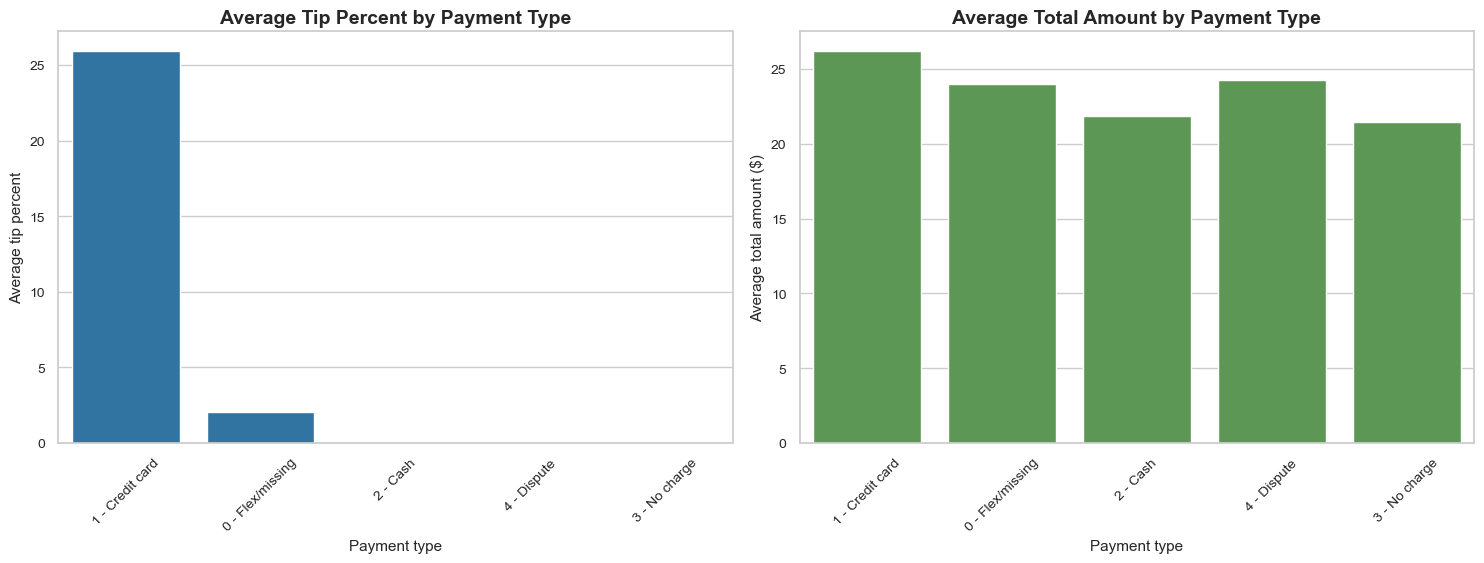

In [17]:
payment_order = payment_metrics.index.tolist()
metric_long = payment_metrics.reset_index().melt(
    id_vars="payment_label",
    value_vars=["avg_tip_percent", "avg_total_amount", "avg_fare_amount"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
sns.barplot(data=payment_metrics.reset_index(), x="payment_label", y="avg_tip_percent", order=payment_order, color=PRIMARY, ax=axes[0])
axes[0].set_title("Average Tip Percent by Payment Type")
axes[0].set_xlabel("Payment type")
axes[0].set_ylabel("Average tip percent")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=payment_metrics.reset_index(), x="payment_label", y="avg_total_amount", order=payment_order, color=GREEN, ax=axes[1])
axes[1].set_title("Average Total Amount by Payment Type")
axes[1].set_xlabel("Payment type")
axes[1].set_ylabel("Average total amount ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

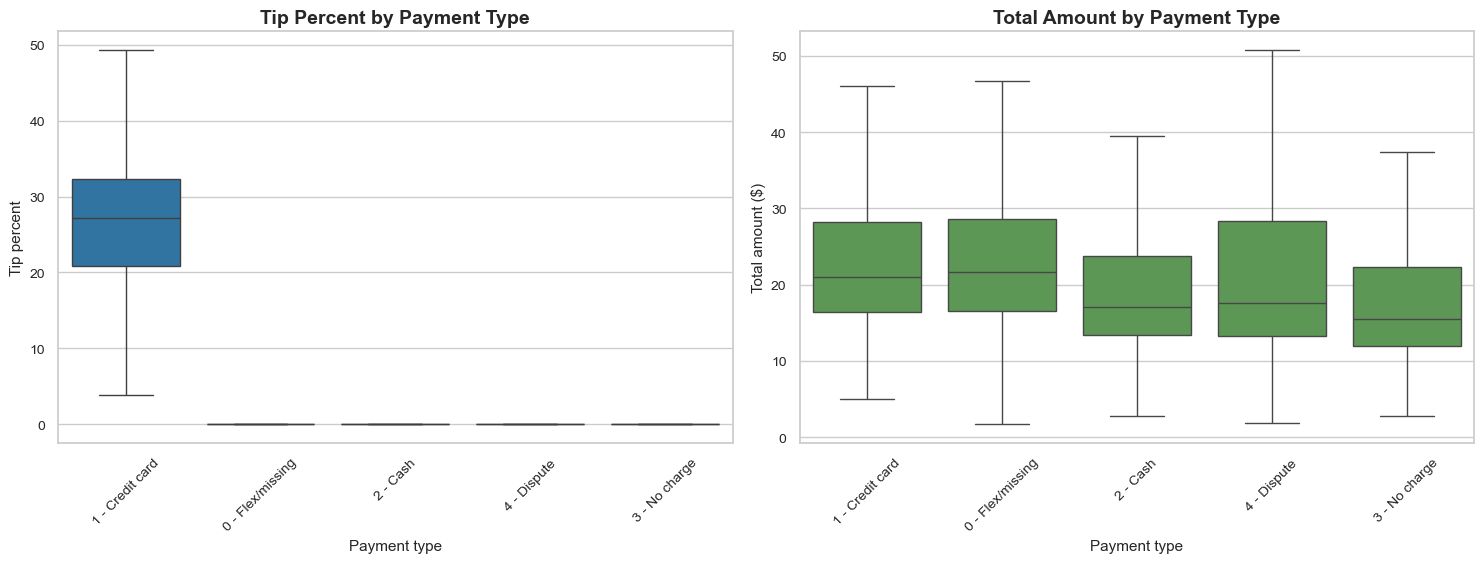

In [18]:
box_sample = sample_for_scatter(common_metric[common_metric["payment_label"].isin(payment_order[:5])], n=180_000)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
sns.boxplot(data=box_sample, x="payment_label", y="tip_percent", order=payment_order[:5], showfliers=False, color=PRIMARY, ax=axes[0])
axes[0].set_title("Tip Percent by Payment Type")
axes[0].set_xlabel("Payment type")
axes[0].set_ylabel("Tip percent")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=box_sample, x="payment_label", y="total_amount", order=payment_order[:5], showfliers=False, color=GREEN, ax=axes[1])
axes[1].set_title("Total Amount by Payment Type")
axes[1].set_xlabel("Payment type")
axes[1].set_ylabel("Total amount ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Credit card trips show much higher recorded tip percentages than cash trips. Cash tips are often not captured in the electronic trip record, producing near-zero recorded tip behavior.

**Interpretation:** Payment type is partly a behavior signal and partly a data-capture signal. Card records are more reliable for tip analysis than cash records.

**Business implication:** Tipping insights and driver-earning discussions should separate card and cash trips instead of reporting one blended average.

# 6. Distance vs Total Amount

This relationship shows how customer payment changes as trip length increases.

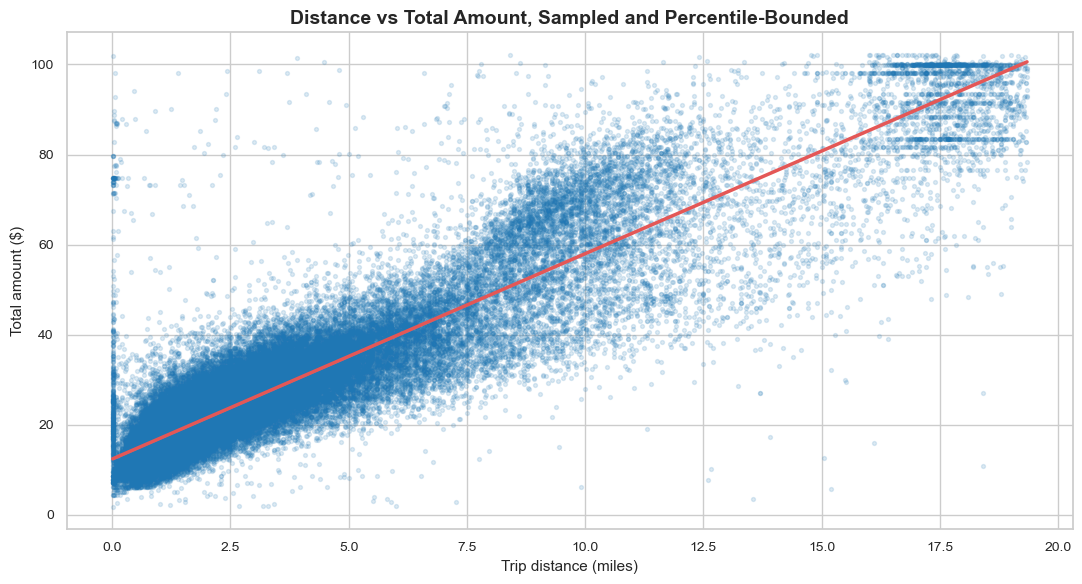

,distance_bin,trips,median_total,avg_total
0,"[0, 1)",2323645,14.06,14.71
1,"[1, 2)",3462982,18.54,18.92
2,"[2, 3)",1688159,23.85,24.19
3,"[3, 4)",800618,28.62,28.97
4,"[4, 5)",432346,32.62,32.79
5,"[5, 6)",275492,36.15,36.15
6,"[6, 7)",197470,39.84,39.93
7,"[7, 8)",150972,44.67,45.26
8,"[8, 9)",156010,54.66,54.03
9,"[9, 10)",154197,62.44,60.26


In [19]:
scatter_amount = sample_for_scatter(common_metric[["trip_distance", "total_amount"]].dropna(), n=120_000)

fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(
    data=scatter_amount,
    x="trip_distance",
    y="total_amount",
    scatter_kws={"s": 8, "alpha": 0.15, "color": PRIMARY},
    line_kws={"color": RED, "linewidth": 2.5},
    ax=ax,
)
ax.set_title("Distance vs Total Amount, Sampled and Percentile-Bounded")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Total amount ($)")
plt.tight_layout()
plt.show()

binned_distance_amount = common_metric.assign(
    distance_bin=pd.cut(common_metric["trip_distance"], bins=np.arange(0, 21, 1), right=False)
).groupby("distance_bin", observed=True).agg(
    trips=("total_amount", "size"),
    median_total=("total_amount", "median"),
    avg_total=("total_amount", "mean"),
).reset_index()
binned_distance_amount.head(10)

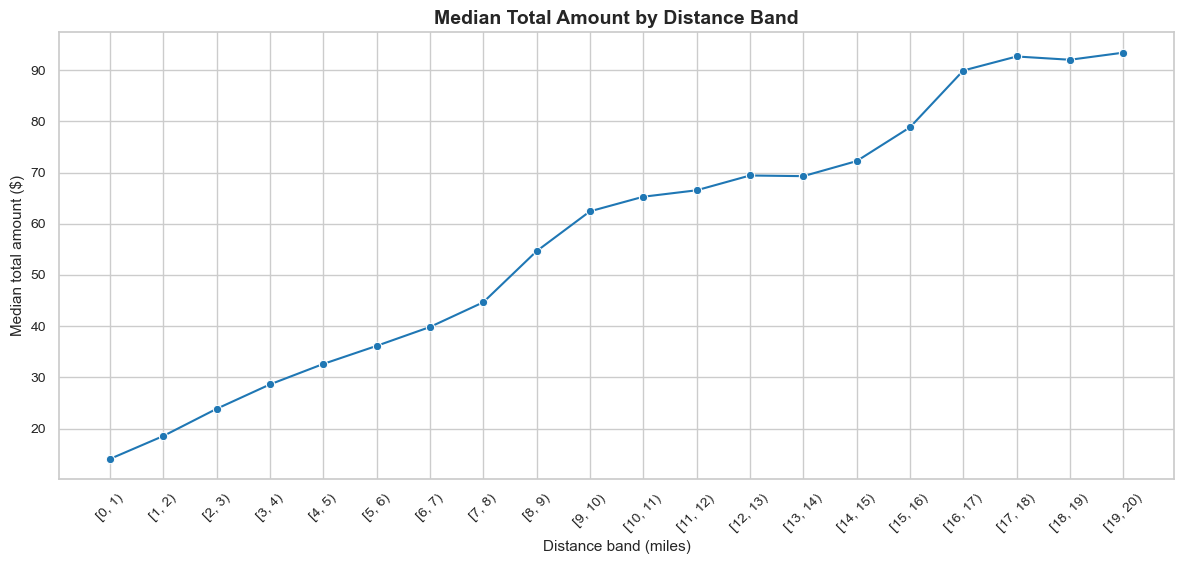

In [20]:
fig, ax = plt.subplots(figsize=(12, 5.8))
binned_distance_amount["bin_label"] = binned_distance_amount["distance_bin"].astype(str)
sns.lineplot(data=binned_distance_amount, x="bin_label", y="median_total", marker="o", color=PRIMARY, ax=ax)
ax.set_title("Median Total Amount by Distance Band")
ax.set_xlabel("Distance band (miles)")
ax.set_ylabel("Median total amount ($)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Total amount rises with trip distance, and the relationship is broadly positive. The increase is not perfectly linear because surcharges, tolls, airport fees, tips, and minimum/flat-fare rules affect the final amount.

**Interpretation:** Distance is one of the strongest drivers of customer payment, but fare policy and add-on charges create visible spread around the trend.

**Business implication:** Long-trip and airport economics should be evaluated separately from short urban trips when discussing fare efficiency and revenue yield.

# 7. Distance vs Duration

Distance, duration, and average speed together show operating efficiency and congestion exposure.

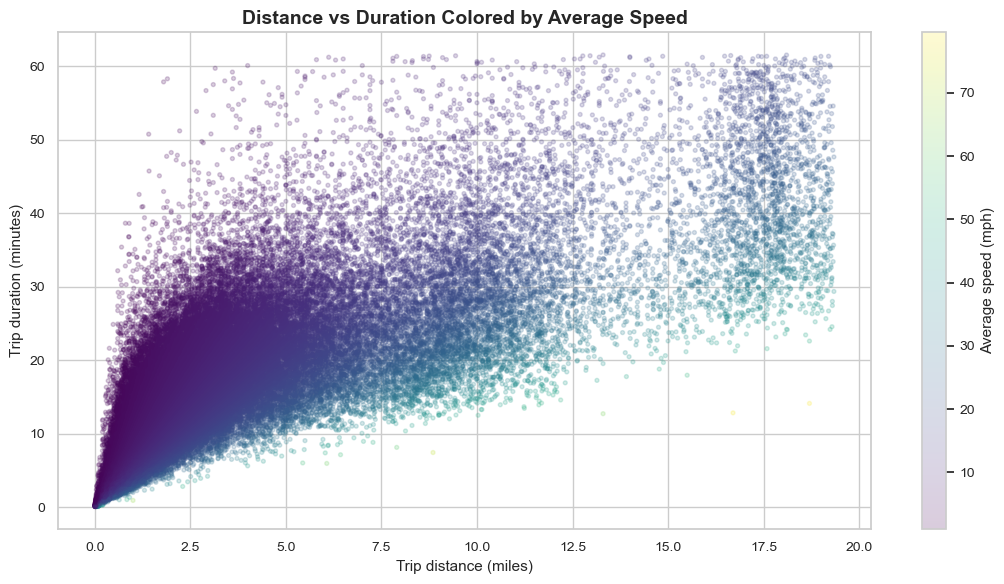

,distance_band,trips,median_duration,median_speed
0,"[0, 1)",2286235,5.43,7.52
1,"[1, 2)",3462617,9.98,8.60
2,"[2, 5)",2920674,16.53,10.44
3,"[5, 10)",933874,23.78,17.65
4,"[10, 20)",480358,35.18,23.60


In [21]:
speed_view = common_metric[
    common_metric["avg_speed_mph"].notna()
    & common_metric["avg_speed_mph"].between(1, 80)
][["trip_distance", "trip_duration_min", "avg_speed_mph"]]
speed_sample = sample_for_scatter(speed_view, n=120_000)

fig, ax = plt.subplots(figsize=(11, 6))
points = ax.scatter(
    speed_sample["trip_distance"],
    speed_sample["trip_duration_min"],
    c=speed_sample["avg_speed_mph"],
    cmap="viridis",
    s=8,
    alpha=0.20,
)
ax.set_title("Distance vs Duration Colored by Average Speed")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Trip duration (minutes)")
cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Average speed (mph)")
plt.tight_layout()
plt.show()

speed_summary = speed_view.assign(
    distance_band=pd.cut(speed_view["trip_distance"], bins=[0, 1, 2, 5, 10, 20], right=False)
).groupby("distance_band", observed=True).agg(
    trips=("avg_speed_mph", "size"),
    median_duration=("trip_duration_min", "median"),
    median_speed=("avg_speed_mph", "median"),
).reset_index()
speed_summary

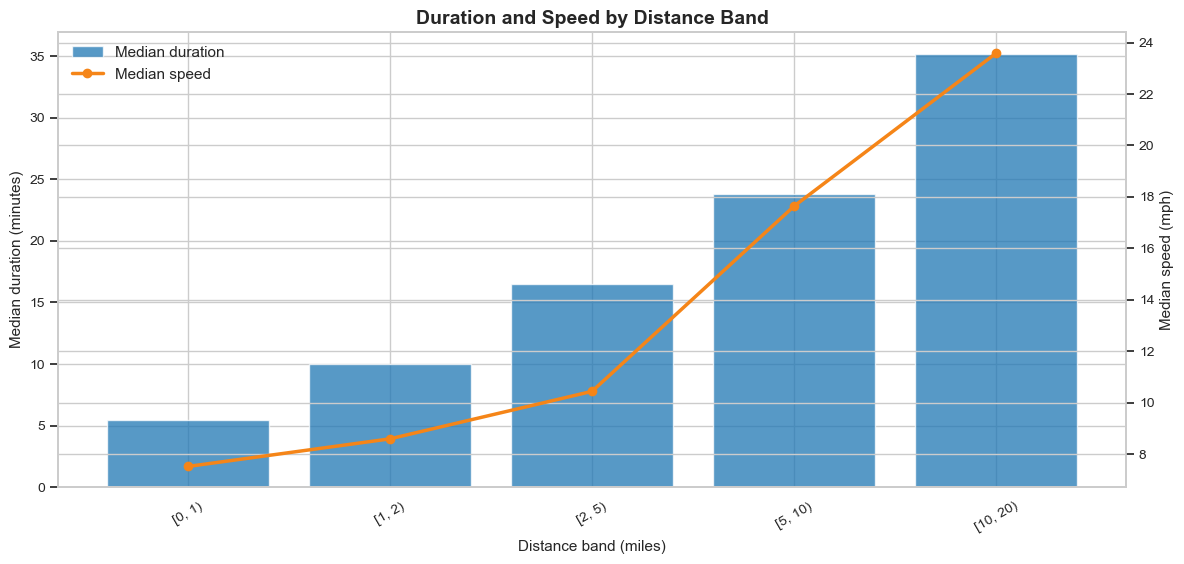

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 5.8))
labels = speed_summary["distance_band"].astype(str)
ax1.bar(labels, speed_summary["median_duration"], color=PRIMARY, alpha=0.75, label="Median duration")
ax1.set_xlabel("Distance band (miles)")
ax1.set_ylabel("Median duration (minutes)")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(labels, speed_summary["median_speed"], marker="o", color=ACCENT, linewidth=2.5, label="Median speed")
ax2.set_ylabel("Median speed (mph)")

ax1.set_title("Duration and Speed by Distance Band")
lines, labels_1 = ax1.get_legend_handles_labels()
lines2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_1 + labels_2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** Duration increases with distance, but short trips can still take meaningful time. Longer trips generally show higher average speeds because they are more likely to include highway or airport movement.

**Interpretation:** Congestion is most visible in short urban trips where duration is high relative to distance.

**Business implication:** Operational efficiency should not be judged by distance alone. Dense-city trips need separate monitoring because they consume vehicle time without producing long-trip mileage.

# 8. Hour vs Revenue

This section compares total revenue by hour with revenue per trip by hour to separate demand volume from trip value.

In [23]:
hour_revenue = analysis.groupby("pickup_hour").agg(
    trips=("total_amount", "size"),
    recorded_revenue=("total_amount", "sum"),
    revenue_per_trip=("total_amount", "mean"),
).sort_index()
hour_revenue.sort_values("recorded_revenue", ascending=False).head(10)

,trips,recorded_revenue,revenue_per_trip
pickup_hour,,,
18,843230,"21,034,291.17",24.94
17,773718,"20,548,753.94",26.56
16,668340,"18,742,590.67",28.04
19,741431,"18,705,254.66",25.23
21,695496,"17,435,476.47",25.07
15,648415,"17,303,236.00",26.69
20,683827,"16,941,919.60",24.78
14,615974,"16,476,289.40",26.75
22,634750,"16,102,118.60",25.37


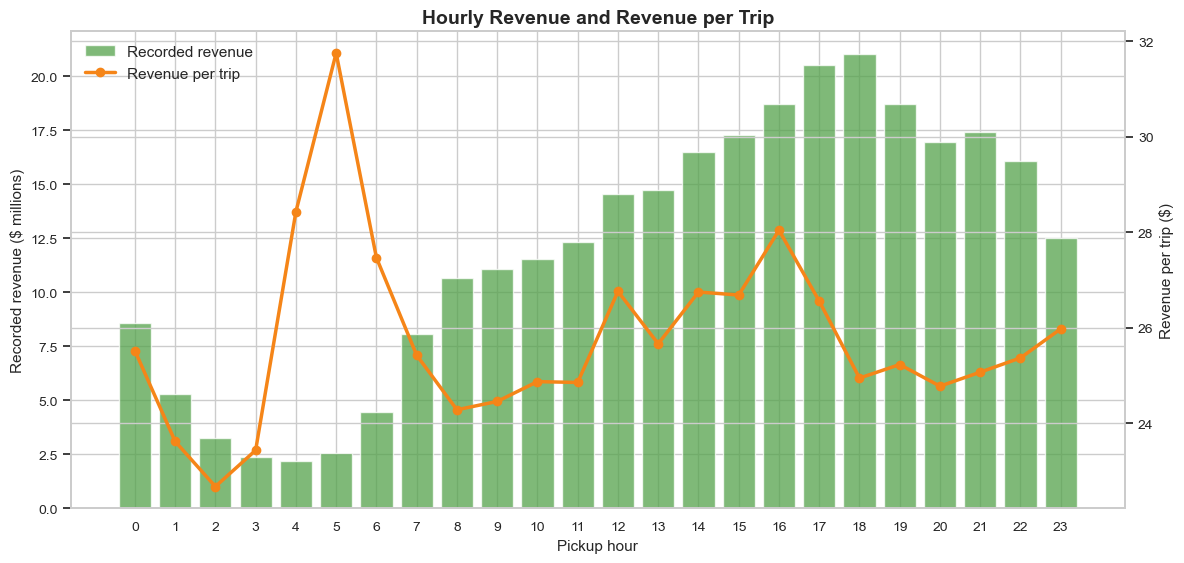

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 5.8))
ax1.bar(hour_revenue.index, hour_revenue["recorded_revenue"] / 1_000_000, color=GREEN, alpha=0.75, label="Recorded revenue")
ax1.set_xlabel("Pickup hour")
ax1.set_ylabel("Recorded revenue ($ millions)")
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hour_revenue.index, hour_revenue["revenue_per_trip"], color=ACCENT, marker="o", linewidth=2.5, label="Revenue per trip")
ax2.set_ylabel("Revenue per trip ($)")

ax1.set_title("Hourly Revenue and Revenue per Trip")
lines, labels_1 = ax1.get_legend_handles_labels()
lines2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_1 + labels_2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** Evening hours generate the most total revenue because they combine high trip volume with solid revenue per trip. Some lower-volume hours can still show comparatively high revenue per trip.

**Interpretation:** The most profitable operating windows are not only the highest-value trips; they are the hours where volume and value overlap.

**Business implication:** Late afternoon and evening coverage should be prioritized for revenue capture, while high revenue-per-trip off-peak windows may be useful for targeted airport or long-trip strategies.

# 9. Borough vs Average Trip Metrics

Borough-level comparisons summarize differences in trip length, duration, customer payment, and tip behavior.

In [25]:
borough_metrics = common_metric.groupby("pickup_borough").agg(
    trips=("total_amount", "size"),
    avg_trip_duration=("trip_duration_min", "mean"),
    avg_trip_distance=("trip_distance", "mean"),
    avg_total_amount=("total_amount", "mean"),
    avg_tip_percent=("tip_percent", "mean"),
).query("trips >= 500").sort_values("trips", ascending=False)
borough_metrics

,trips,avg_trip_duration,avg_trip_distance,avg_total_amount,avg_tip_percent
pickup_borough,,,,,
Manhattan,9091937,12.86,2.22,22.61,19.66
Queens,711211,27.48,9.86,58.81,14.10
Brooklyn,239693,22.17,4.67,28.12,2.25
Bronx,56891,22.53,5.85,29.12,0.28
Unknown,22056,14.13,3.10,27.38,20.61
Staten Island,676,20.68,7.59,35.90,0.53


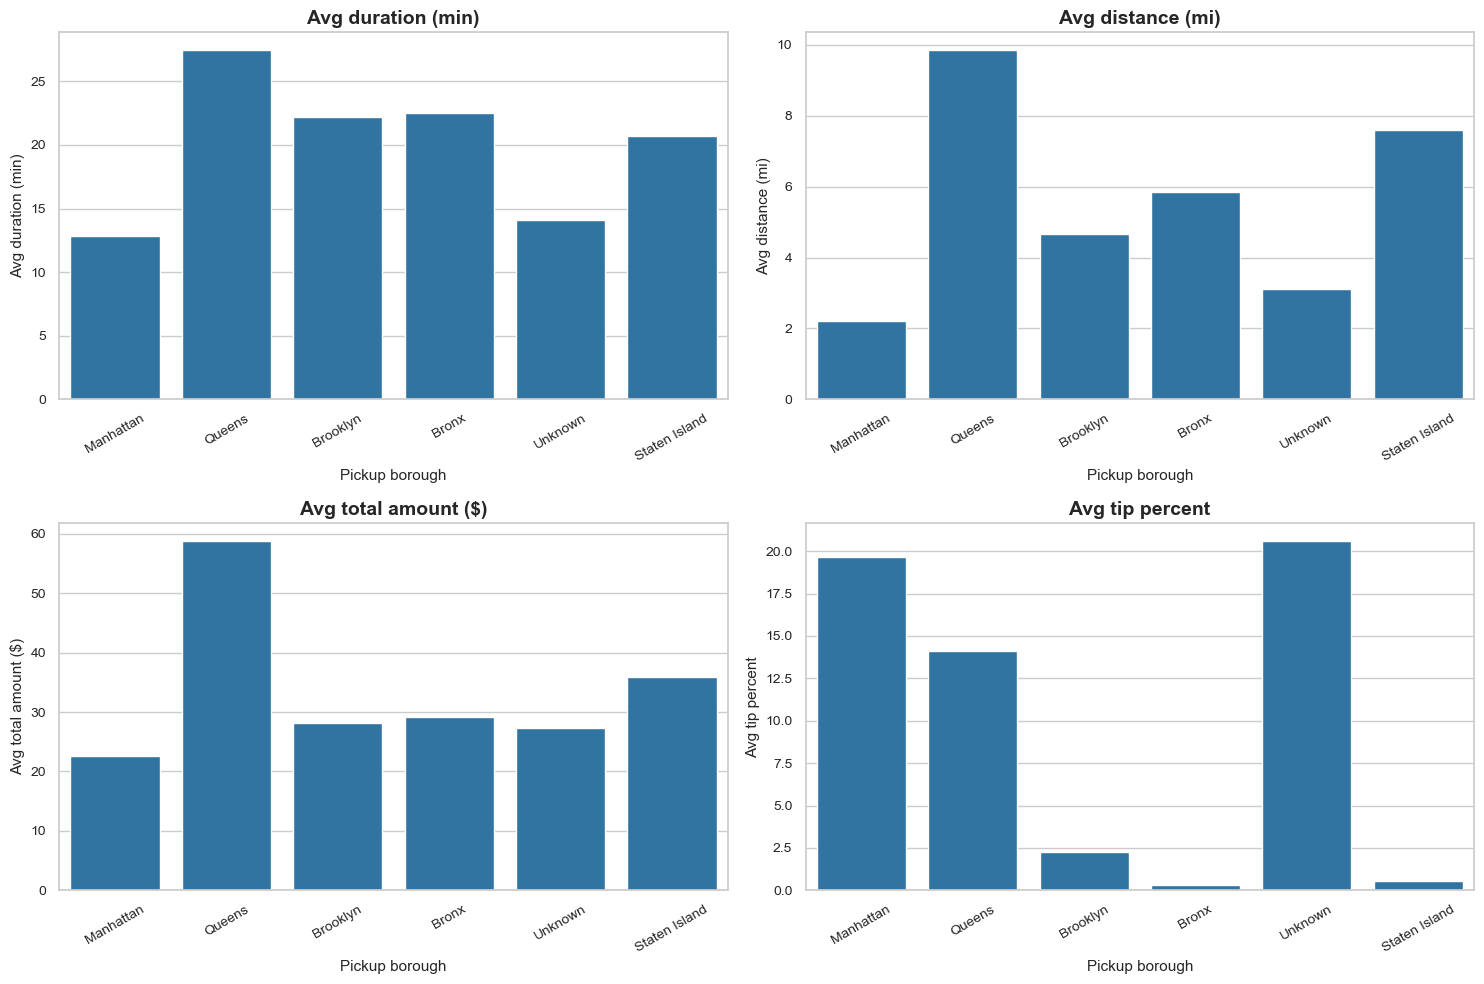

In [26]:
borough_long = borough_metrics.reset_index().melt(
    id_vars=["pickup_borough", "trips"],
    value_vars=["avg_trip_duration", "avg_trip_distance", "avg_total_amount", "avg_tip_percent"],
    var_name="metric",
    value_name="value",
)

metric_titles = {
    "avg_trip_duration": "Avg duration (min)",
    "avg_trip_distance": "Avg distance (mi)",
    "avg_total_amount": "Avg total amount ($)",
    "avg_tip_percent": "Avg tip percent",
}
borough_long["metric"] = borough_long["metric"].map(metric_titles)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), metric_titles.values()):
    subset = borough_long[borough_long["metric"].eq(metric)]
    sns.barplot(data=subset, x="pickup_borough", y="value", color=PRIMARY, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Pickup borough")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Manhattan has the largest trip base and shorter average trips. Queens has higher average distance and total amount, reflecting airport-linked and longer-distance activity. EWR has high total amounts but small volume.

**Interpretation:** Boroughs represent different operating profiles: Manhattan is a dense high-throughput market, while Queens and airport-related areas are higher-value, longer-trip markets.

**Business implication:** Borough performance should be evaluated using both volume and trip economics. A single average across all boroughs hides important operating differences.

# Top Operational and Business Insights

1. Demand peaks in the early evening, especially around 18:00, making late afternoon through evening the strongest coverage window.
2. Saturday, Thursday, and Friday are high-demand days, so weekend service should not be treated as secondary.
3. Manhattan dominates trip volume and total revenue, while airport zones generate high-value trips with much higher average fares.
4. Credit card trips show much higher recorded tip percentages than cash trips, making payment type essential for interpreting tipping behavior.
5. Distance is strongly related to total amount, but surcharges, tolls, airport fees, and fare rules create spread around the trend.
6. Distance and duration move together, but short urban trips can have low speed and high time cost, indicating congestion exposure.

# Strongest Relationships Found

- **Trip distance and total amount:** strong positive relationship; longer trips usually cost more, though fare components create variation.
- **Pickup hour and trip volume/revenue:** early evening hours concentrate both demand and revenue.
- **Geography and trip economics:** Manhattan drives volume, while airports and Queens-linked trips drive higher average totals.
- **Distance and duration:** generally positive relationship, with average speed showing how congestion changes efficiency by trip type.